In [1]:
import os
import sys
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")

/home/iasudakov/miniconda3/envs/DiT/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# def compute_drift(gen: torch.Tensor, pos: torch.Tensor, t: float = 0.5):
#     """
#     Compute drift field V with attention-based kernel.

#     Args:
#         gen: Generated samples [G, D]
#         pos: Data samples [P, D]
#         temp: Temperature for softmax kernel

#     Returns:
#         V: Drift vectors [G, D]
#     """

#     diff = (gen.unsqueeze(1) - t*pos.unsqueeze(0))/(1-t)  # (100, 500, d)
#     norms = torch.exp(-0.5 * (diff**2).sum(dim=-1))  # (100, 500)

#     numerator = (pos.unsqueeze(0) * norms.unsqueeze(-1)).mean(dim=1)
#     denumerator = (norms.unsqueeze(-1)).mean(dim=1)

#     return (numerator / denumerator - gen) / (1 - t)

In [19]:
def compute_drift(gen: torch.Tensor, pos: torch.Tensor, t: float = 0.5):
    """
    Compute drift field V with attention-based kernel.

    Args:
        gen: Generated samples [G=100, D]
        pos: Data samples [P=500, D]
        temp: Temperature for softmax kernel

    Returns:
        V: Drift vectors [G, D]
    """

    diff = (gen.unsqueeze(1) - t*pos.unsqueeze(0))/(1-t)  # (100, 500, d)
    # norms = torch.exp(-0.5 * (diff**2).sum(dim=-1))  # (100, 500)

    dists = -0.5 * (diff**2).sum(dim=-1)  # (100, 500)

    weights = torch.softmax(dists, dim=-1) # (100, 500)

    x_0_preds = (pos.unsqueeze(0) * weights.unsqueeze(-1)).sum(dim=1) 

    return (x_0_preds - gen) / (1 - t)


    numerator = (pos.unsqueeze(0) * weights.unsqueeze(-1)).mean(dim=1)
    denumerator = (weights.unsqueeze(-1)).mean(dim=1)

    return (numerator / denumerator - gen) / (1 - t)

## Visualize the Drifting Field

Let's see what the drifting field look like for a randomly initialized $q$.

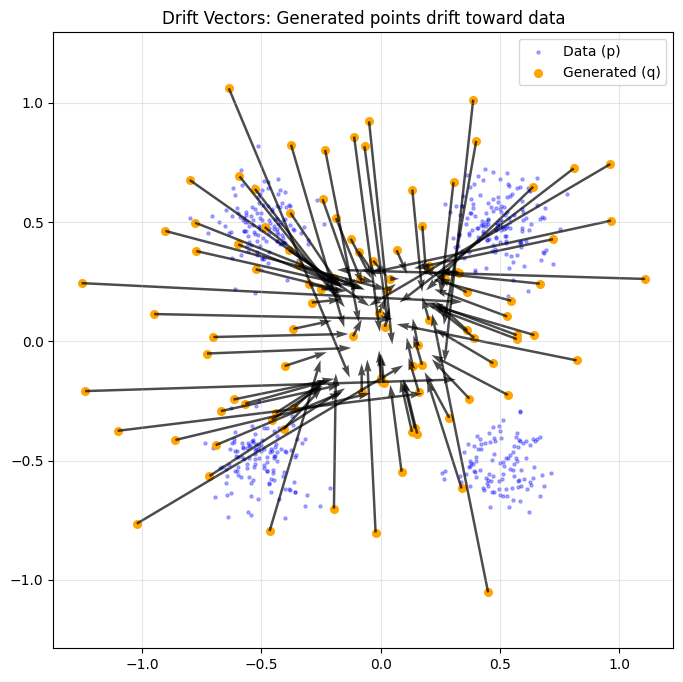

In [20]:
# Quick visualization of drift vectors
torch.manual_seed(42)

# Random generated points (from Gaussian)
gen_test = torch.randn(100, 2) * 0.5

# Target data: simple 4-mode Gaussian mixture
centers = torch.tensor([[-0.5, -0.5], [-0.5, 0.5], [0.5, -0.5], [0.5, 0.5]])
idx = torch.randint(0, 4, (500,))
pos_test = centers[idx] + torch.randn(500, 2) * 0.1

# Compute drift
drift_test = compute_drift(gen_test, pos_test, t=0.6)

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(pos_test[:, 0], pos_test[:, 1], s=5, alpha=0.3, c='blue', label='Data (p)')
plt.scatter(gen_test[:, 0], gen_test[:, 1], s=30, c='orange', label='Generated (q)')
plt.quiver(gen_test[:, 0], gen_test[:, 1], drift_test[:, 0], drift_test[:, 1],
           scale=3, color='black', alpha=0.7, width=0.004)
plt.legend()
plt.title('Drift Vectors: Generated points drift toward data')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

---

# Part 2: Toy 2D Examples

Let's train on 2D distributions to visualize the full training dynamics.

We'll use two classic test distributions:
- **Checkerboard**: 4 diagonally-arranged squares (tests mode coverage)
- **Swiss Roll**: Spiral pattern (tests learning complex geometry)

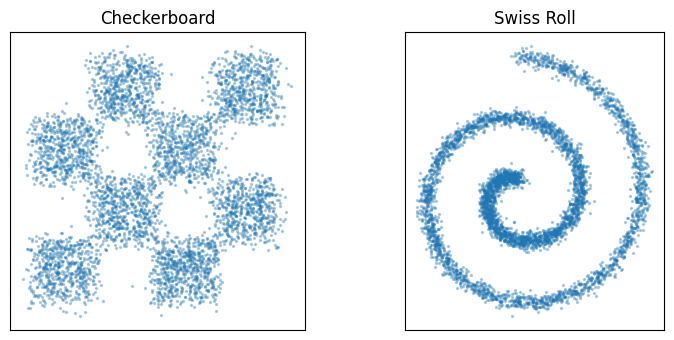

In [21]:
# ============================================================
# Toy Dataset Samplers (minimal; copied from toy_mean_drift.py)
# ============================================================

def sample_checkerboard(n: int, noise: float = 0.05, seed: int | None = None) -> torch.Tensor:
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    b = torch.randint(0, 2, (n,), generator=g)
    i = torch.randint(0, 2, (n,), generator=g) * 2 + b
    j = torch.randint(0, 2, (n,), generator=g) * 2 + b
    u = torch.rand(n, generator=g)
    v = torch.rand(n, generator=g)
    pts = torch.stack([i + u, j + v], dim=1) - 2.0
    pts = pts / 2.0
    if noise > 0:
        pts = pts + noise * torch.randn(pts.shape, generator=g)
    return pts


def sample_swiss_roll(n: int, noise: float = 0.03, seed: int | None = None) -> torch.Tensor:
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    u = torch.rand(n, generator=g)
    t = 0.5 * math.pi + 4.0 * math.pi * u
    pts = torch.stack([t * torch.cos(t), t * torch.sin(t)], dim=1)
    pts = pts / (pts.abs().max() + 1e-8)
    if noise > 0:
        pts = pts + noise * torch.randn(pts.shape, generator=g)
    return pts


# quick look
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, (name, sampler) in zip(axes, [("Checkerboard", sample_checkerboard), ("Swiss Roll", sample_swiss_roll)]):
    pts = sampler(5000).numpy()
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.3)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(name)
plt.tight_layout()
plt.show()

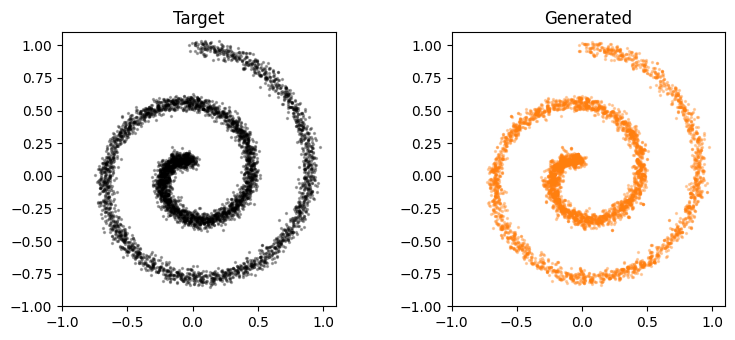

In [22]:
sampler = sample_swiss_roll

vis = torch.randn(5000, 2, device=DEVICE)
gt = sampler(5000).to(device=DEVICE)

ts = torch.linspace(0.01, 0.99, 100)

if len(ts) > 1:
    dt = ts[1] - ts[0]
else:
    dt = 1.0 - ts[0]

for t in ts:
    drift = compute_drift(vis, gt, t=t)
    vis += dt * drift

vis = vis.cpu().numpy()
gt = gt.cpu().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
ax1.scatter(gt[:, 0], gt[:, 1], s=2, alpha=0.3, c='black')
ax1.set_title('Target'); ax1.set_aspect('equal'); 
# ax1.axis('off')
ax1.set_xlim(-1.0, 1.1)
ax1.set_ylim(-1.0, 1.1)
ax2.scatter(vis[:, 0], vis[:, 1], s=2, alpha=0.3, c='tab:orange')
ax2.set_title(f'Generated'); ax2.set_aspect('equal');
# ax2.axis('off')
ax2.set_xlim(-1.0, 1.1)
ax2.set_ylim(-1.0, 1.1)
plt.tight_layout(); plt.show()

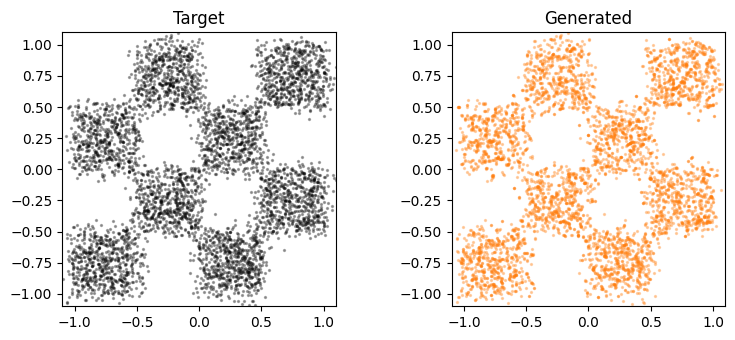

In [23]:
sampler = sample_checkerboard

vis = torch.randn(5000, 2, device=DEVICE)
gt = sampler(5000).to(device=DEVICE)

ts = torch.linspace(0.01, 0.99, 100)

if len(ts) > 1:
    dt = ts[1] - ts[0]
else:
    dt = 1.0 - ts[0]

for t in ts:
    drift = compute_drift(vis, gt, t=t)
    vis += dt * drift

vis = vis.cpu().numpy()
gt = gt.cpu().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
ax1.scatter(gt[:, 0], gt[:, 1], s=2, alpha=0.3, c='black')
ax1.set_title('Target'); ax1.set_aspect('equal'); 
# ax1.axis('off')
ax1.set_xlim(-1.1, 1.1)
ax1.set_ylim(-1.1, 1.1)
ax2.scatter(vis[:, 0], vis[:, 1], s=2, alpha=0.3, c='tab:orange')
ax2.set_title(f'Generated'); ax2.set_aspect('equal');
# ax2.axis('off')
ax2.set_xlim(-1.1, 1.1)
ax2.set_ylim(-1.1, 1.1)
plt.tight_layout(); plt.show()

### MNIST

In [36]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert to tensor (0-1 range)
    transforms.Normalize((0.5,), (0.5,))  # Normalize with MNIST mean & std
])

# Load training data
train_dataset = datasets.MNIST(
    root='./data',           # Where to store data
    train=True,              # Training set
    download=True,           # Download if not present
    transform=transform
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=1000,
    shuffle=True,
    num_workers=2
)

In [37]:
def plot_batch_grid(images, n_columns=None, figsize=(3, 3), title=None):

    # images [bs, 784]
    images = images.reshape((images.shape[0], 1, 28, 28))

    images_np = images.detach().cpu().squeeze().numpy()    
    n_images = len(images_np)
    
    if n_columns is None:
        n_columns = int(np.ceil(np.sqrt(n_images)))
    n_rows = int(np.ceil(n_images / n_columns))
    
    figure, axes = plt.subplots(n_rows, n_columns, squeeze=False, constrained_layout=True)
    figure.set_figwidth(figsize[0] * n_columns)
    figure.set_figheight(figsize[1] * n_rows)

    for index in range(n_images):
        row = index // n_columns
        column = index % n_columns
        ax = axes[row, column]
        
        image = images_np[index]
        ax.imshow(image, cmap='gray')
        ax.axis('off')

    for index in range(n_images, n_rows * n_columns):
        row = index // n_columns
        column = index % n_columns
        axes[row, column].axis('off')

    if title:
        figure.suptitle(title, fontsize=14, y=1.02)
    
    plt.show()

In [38]:
for batch in train_loader:
    break

In [39]:
batch[0].reshape((-1, 784))[0].min()

tensor(-1.)

In [40]:
def compute_drift(gen: torch.Tensor, pos: torch.Tensor, t: float = 0.5):
    """
    Compute drift field V with attention-based kernel.

    Args:
        gen: Generated samples [G, D]
        pos: Data samples [P, D]
        temp: Temperature for softmax kernel

    Returns:
        V: Drift vectors [G, D]
    """

    diff = (gen.unsqueeze(1) - t*pos.unsqueeze(0))/(1-t)  # (100, 500, d)
    norms = torch.exp(-0.5 * (diff**2).sum(dim=-1) / 1000)  # (100, 500)

    numerator = (pos.unsqueeze(0) * norms.unsqueeze(-1)).mean(dim=1)
    denumerator = (norms.unsqueeze(-1)).mean(dim=1)

    return (numerator / denumerator - gen) / (1 - t)

In [44]:
vis = torch.randn(64, 784, device=DEVICE)

gt = batch[0].reshape(batch[0].shape[0], -1).to(device=DEVICE)

ts = torch.linspace(0.1, 0.99, 1000)

if len(ts) > 1:
    dt = ts[1] - ts[0]
else:
    dt = 1.0 - ts[0]

for t in ts:
    drift = compute_drift(vis, gt, t=t)
    vis += dt * drift

    print(vis[0][0])

tensor(-1.7237, device='cuda:0')
tensor(-1.7229, device='cuda:0')
tensor(-1.7222, device='cuda:0')
tensor(-1.7215, device='cuda:0')
tensor(-1.7208, device='cuda:0')
tensor(-1.7201, device='cuda:0')
tensor(-1.7194, device='cuda:0')
tensor(-1.7186, device='cuda:0')
tensor(-1.7179, device='cuda:0')
tensor(-1.7172, device='cuda:0')
tensor(-1.7165, device='cuda:0')
tensor(-1.7158, device='cuda:0')
tensor(-1.7151, device='cuda:0')
tensor(-1.7143, device='cuda:0')
tensor(-1.7136, device='cuda:0')
tensor(-1.7129, device='cuda:0')
tensor(-1.7122, device='cuda:0')
tensor(-1.7115, device='cuda:0')
tensor(-1.7108, device='cuda:0')
tensor(-1.7100, device='cuda:0')
tensor(-1.7093, device='cuda:0')
tensor(-1.7086, device='cuda:0')
tensor(-1.7079, device='cuda:0')
tensor(-1.7072, device='cuda:0')
tensor(-1.7065, device='cuda:0')
tensor(-1.7057, device='cuda:0')
tensor(-1.7050, device='cuda:0')
tensor(-1.7043, device='cuda:0')
tensor(-1.7036, device='cuda:0')
tensor(-1.7029, device='cuda:0')
tensor(-1.

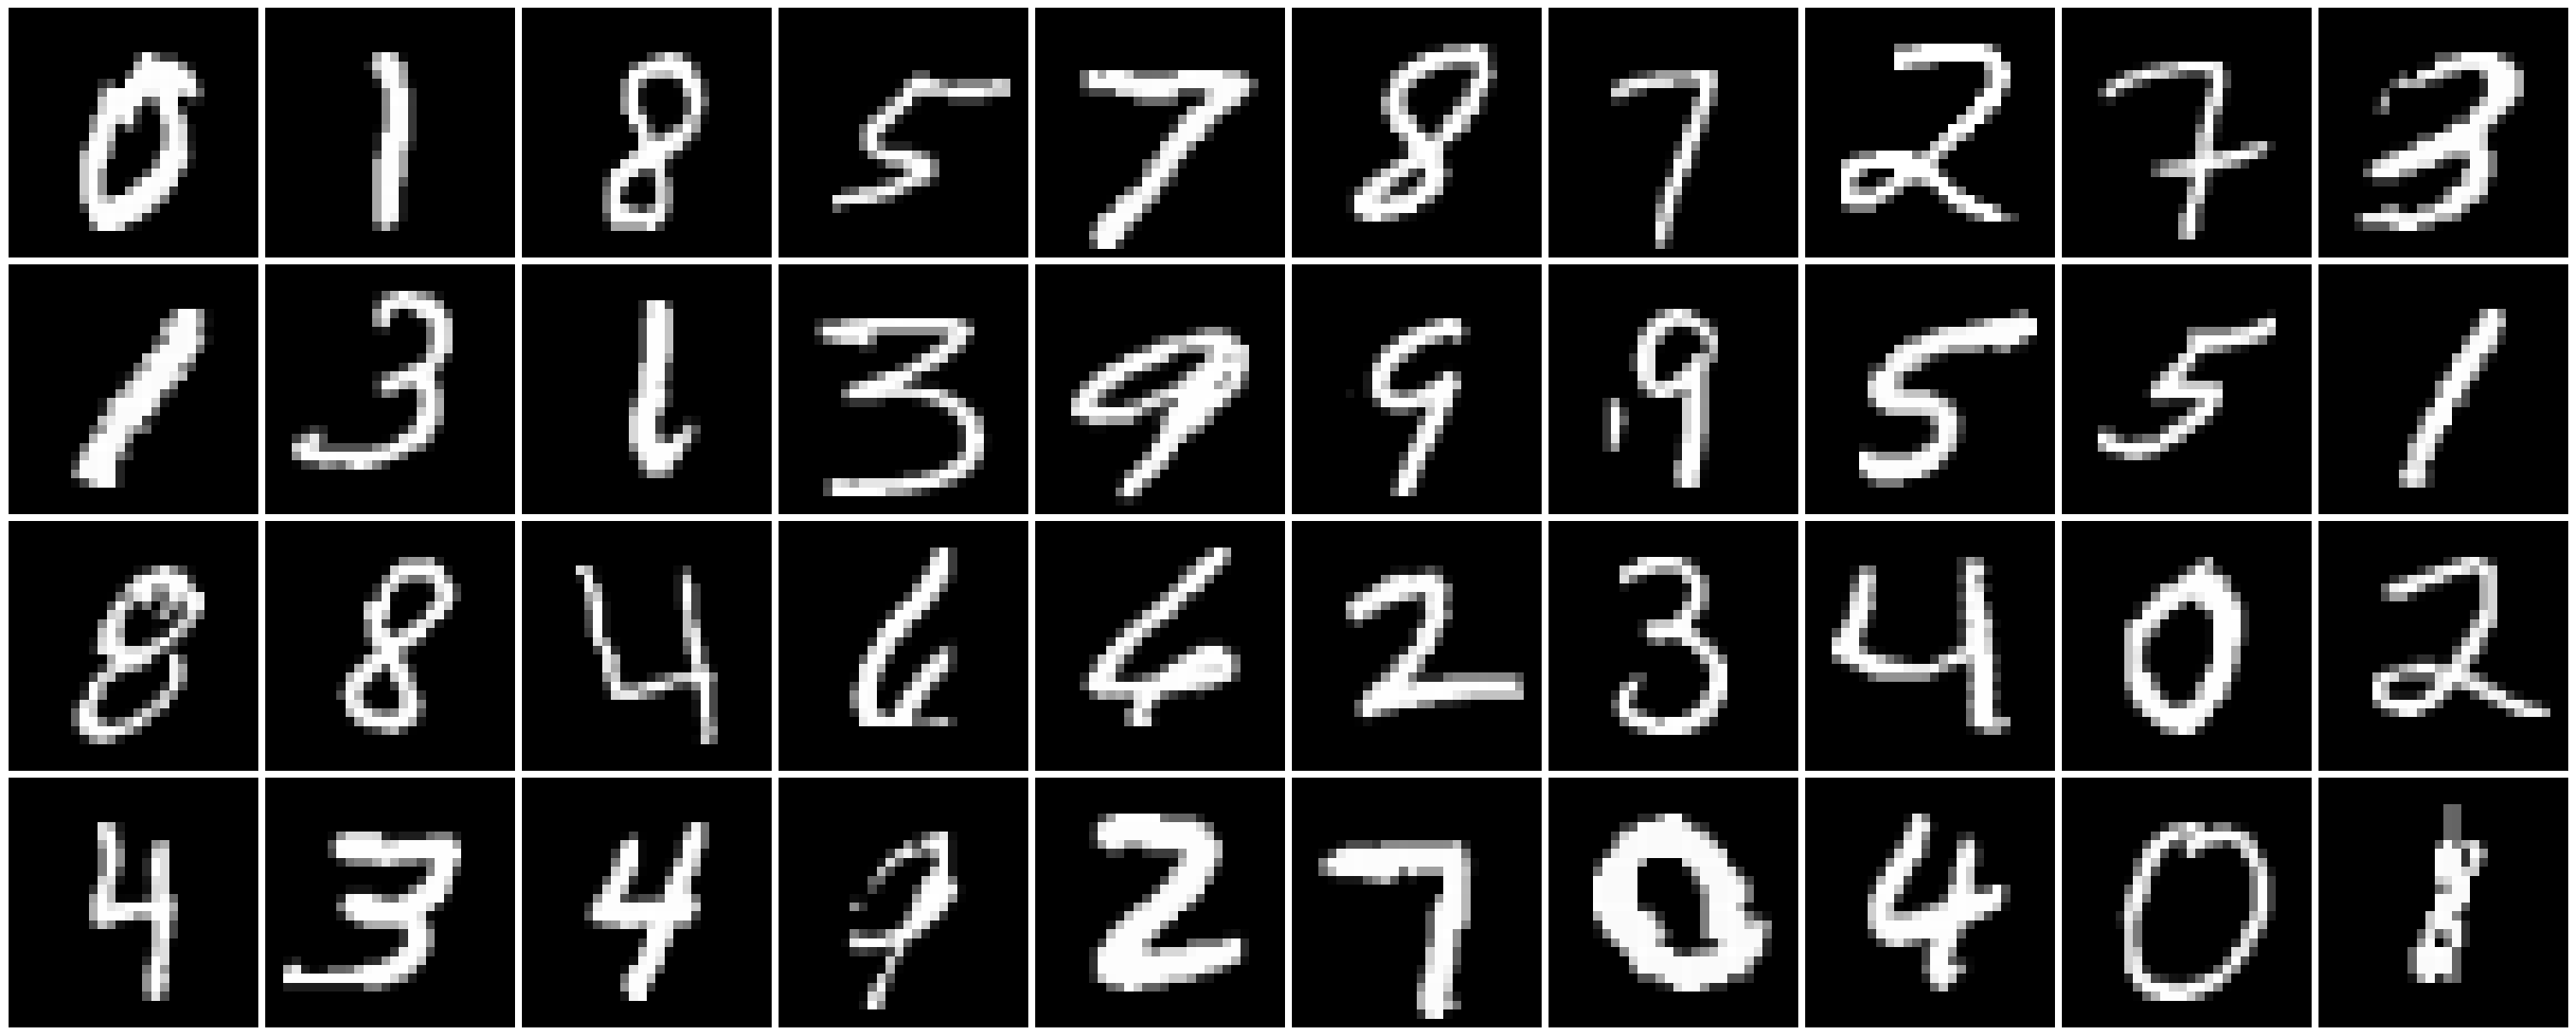

In [45]:
plot_batch_grid(gt[:40], 10)

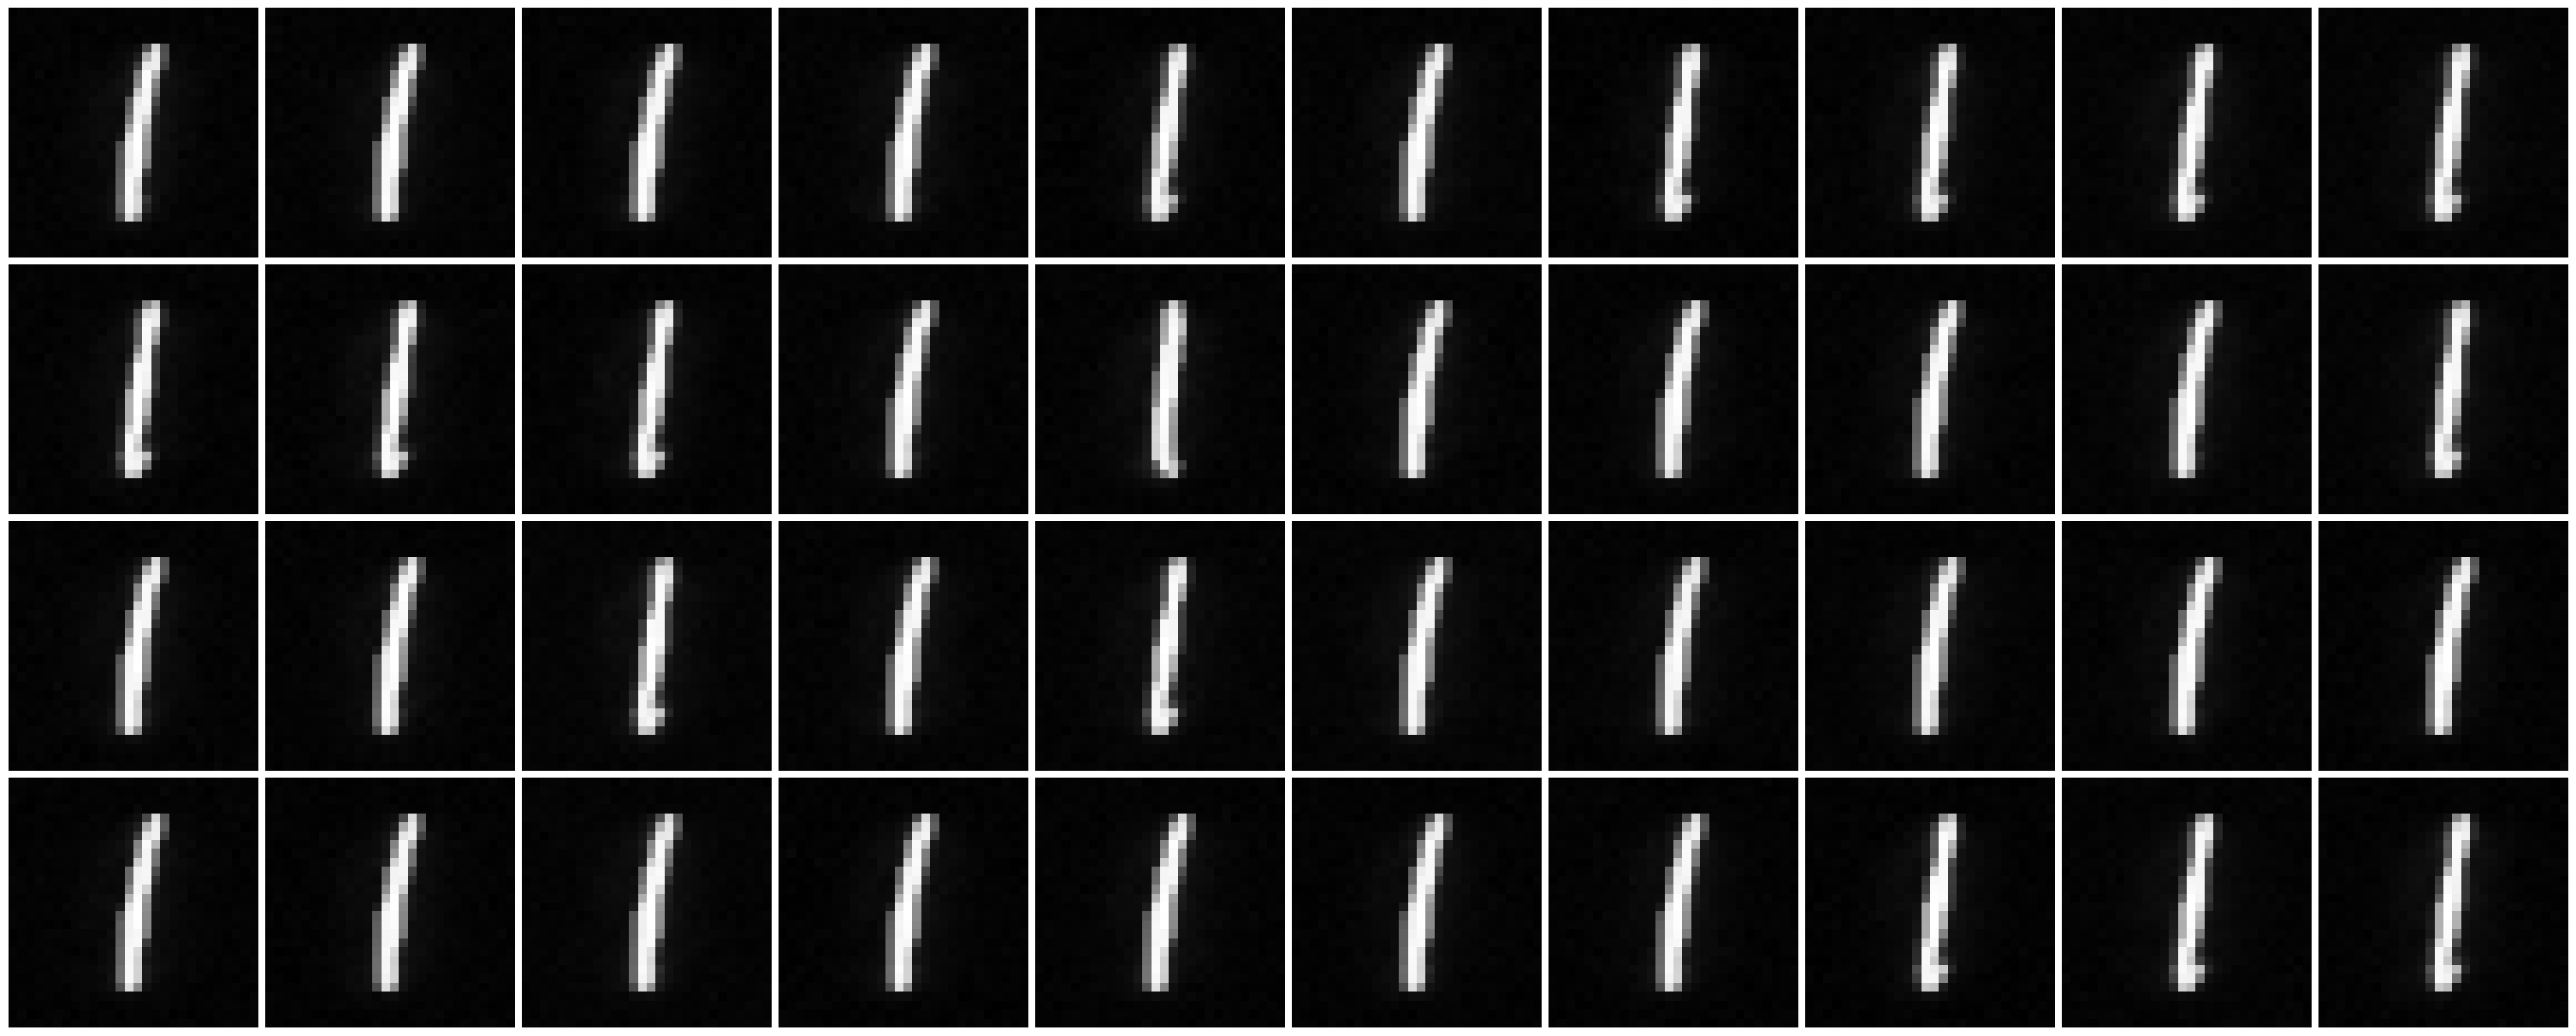

In [46]:
plot_batch_grid(vis[:40], 10)